<a href="https://colab.research.google.com/github/wwvvlllttggiitt/ADII/blob/main/titanic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1. Импорт библиотек

In [62]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report, RocCurveDisplay
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.inspection import permutation_importance

plt.style.use('seaborn-v0_8')
sns.set(font_scale=1.1)

## 2. загрузка, таргет

In [63]:
df = pd.read_csv('/content/Titanic.csv')
print(f"Размер датасета: {df.shape[0]} строк, {df.shape[1]} столбцов")
df.head()

Размер датасета: 891 строк, 12 столбцов


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [64]:
df = df.drop(columns=["Unnamed: 0"], errors="ignore")
target = "Survived"
if target not in df.columns:
    raise ValueError(f"Не найден таргет '{target}'. Колонки: {list(df.columns)}")
print(f"Целевая переменная: '{target}'")

Целевая переменная: 'Survived'


## 3. Гипотезы (формулировка)

Перед анализом сформулируем несколько гипотез, которые будем проверять:

1. **Гипотеза 1:** Женщины выживали значительно чаще мужчин.
2. **Гипотеза 2:** Пассажиры 1 класса чаще выживали.
3. **Гипотеза 3:** Дети (до 12 лет) выживали чаще взрослых.
4. **Гипотеза 4:** Более высокая стоимость билета (Fare) коррелирует с выживанием.

## 4. Первичный анализ данных (EDA)


 Пропущенные значения:


,0
Cabin,687
Age,177
Embarked,2



 Распределение целевой переменной Survived:


,count
Survived,
0,549
1,342


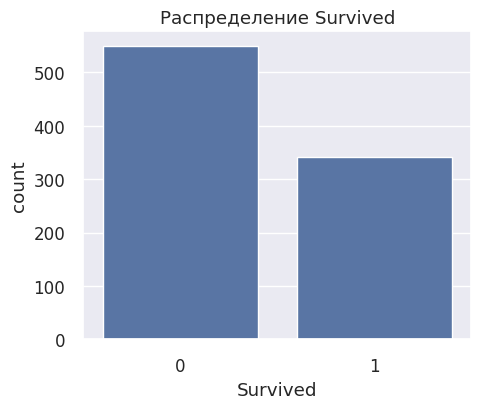

 Есть пропуски ( Age, Cabin, Embarked). В дальнейшем применим фичу 'Cabin_known'.


In [65]:
print("\n Пропущенные значения:")
na_cnt = df.isna().sum().sort_values(ascending=False)
display(na_cnt[na_cnt > 0])

print("\n Распределение целевой переменной Survived:")
surv_counts = df[target].value_counts()
display(surv_counts)

plt.figure(figsize=(5,4))
plt.title("Распределение Survived")
sns.countplot(x=df[target])
plt.show()

print(" Есть пропуски ( Age, Cabin, Embarked). В дальнейшем применим фичу 'Cabin_known'.")


 Женщины выживали чаще мужчин


Survived,0,1
Sex,,
female,0.257962,0.742038
male,0.811092,0.188908


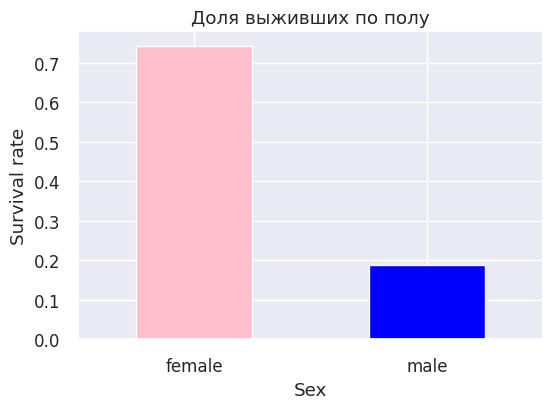

Вывод: доля выживших женщин 74.2%, мужчин 18.9%. Гипотеза подтверждена.


In [66]:
# Гипотеза 1: Пол и выживаемость

print("\n Женщины выживали чаще мужчин")
pivot_sex = pd.crosstab(df["Sex"], df[target], normalize="index")
display(pivot_sex)

plt.figure(figsize=(6,4))
plt.title("Доля выживших по полу")
pivot_sex[1].plot(kind='bar', color=['pink', 'blue'])
plt.ylabel('Survival rate')
plt.xticks(rotation=0)
plt.show()

surv_rate_female = pivot_sex.loc['female', 1]
surv_rate_male = pivot_sex.loc['male', 1]

print(f"Вывод: доля выживших женщин {surv_rate_female:.1%}, мужчин {surv_rate_male:.1%}. Гипотеза подтверждена.")


 Пассажиры 1 класса выживали чаще


,Survived
Pclass,
1,0.629630
2,0.472826
3,0.242363


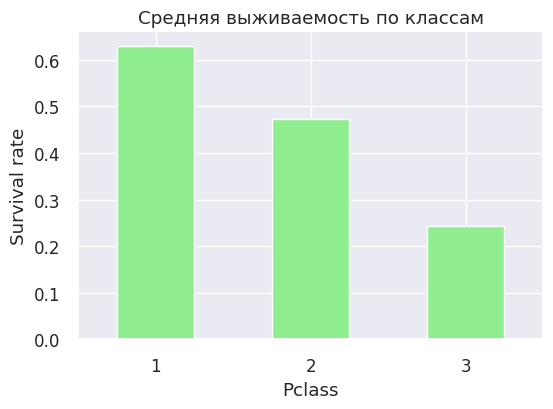

Вывод: выживаемость в 1 классе 63.0%, во 2-м 47.3%, в 3-м 24.2%. Гипотеза подтверждена.


In [67]:
# Гипотеза 2: Класс каюты и выживаемость

print("\n Пассажиры 1 класса выживали чаще")
pivot_pclass = df.groupby("Pclass")[target].mean().sort_index()
display(pivot_pclass)

plt.figure(figsize=(6,4))
plt.title("Средняя выживаемость по классам")
pivot_pclass.plot(kind='bar', color='lightgreen')
plt.ylabel('Survival rate')
plt.xlabel('Pclass')
plt.xticks(rotation=0)
plt.show()

print(f"Вывод: выживаемость в 1 классе {pivot_pclass[1]:.1%}, во 2-м {pivot_pclass[2]:.1%}, в 3-м {pivot_pclass[3]:.1%}. Гипотеза подтверждена.")


 Дети выживали чаще взрослых


,Survived
Child,
0,0.368165
1,0.573529


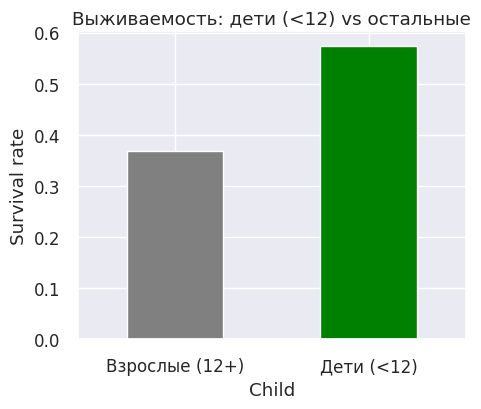

Вывод: дети выживали в 57.4% случаев, взрослые – в 36.8%. Гипотеза подтверждена.


In [68]:
# Гипотеза 3: Возраст и выживаемость (дети)

print("\n Дети выживали чаще взрослых")
df['Child'] = (df['Age'] < 12).astype(int)
pivot_child = df.groupby('Child')[target].mean()
display(pivot_child)

plt.figure(figsize=(5,4))
plt.title("Выживаемость: дети (<12) vs остальные")
pivot_child.plot(kind='bar', color=['gray', 'green'])
plt.ylabel('Survival rate')
plt.xticks([0,1], ['Взрослые (12+)', 'Дети (<12)'], rotation=0)
plt.show()

print(f"Вывод: дети выживали в {pivot_child[1]:.1%} случаев, взрослые – в {pivot_child[0]:.1%}. Гипотеза подтверждена.")


 Более дорогие билеты – выше шанс выжить


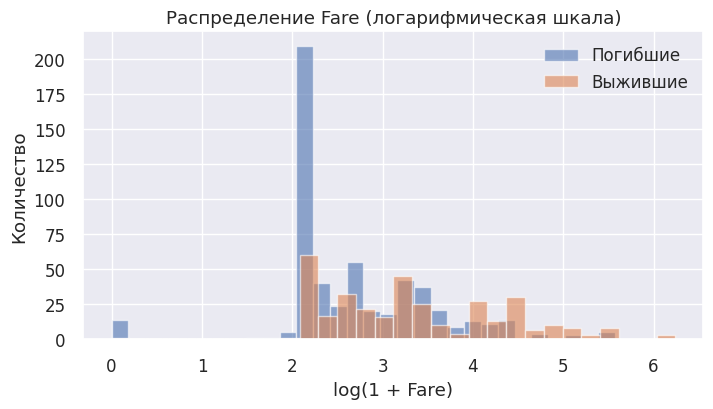

Корреляция Пирсона Fare vs Survived: 0.257
Вывод: у выживших распределение Fare смещено вправо. Гипотеза подтверждена.


In [69]:
# Гипотеза 4: Стоимость билета и выживаемость

print("\n Более дорогие билеты – выше шанс выжить")
fare_surv = df.loc[df[target] == 1, "Fare"].dropna()
fare_dead = df.loc[df[target] == 0, "Fare"].dropna()

plt.figure(figsize=(8,4))
plt.title("Распределение Fare (логарифмическая шкала)")
plt.hist(np.log1p(fare_dead), bins=30, alpha=0.6, label="Погибшие")
plt.hist(np.log1p(fare_surv), bins=30, alpha=0.6, label="Выжившие")
plt.xlabel("log(1 + Fare)")
plt.ylabel("Количество")
plt.legend()
plt.show()

corr_fare = df['Fare'].corr(df[target])
print(f"Корреляция Пирсона Fare vs Survived: {corr_fare:.3f}")
print("Вывод: у выживших распределение Fare смещено вправо. Гипотеза подтверждена.")

## 5. Корреляционный анализ (Пирсон и Спирмен)

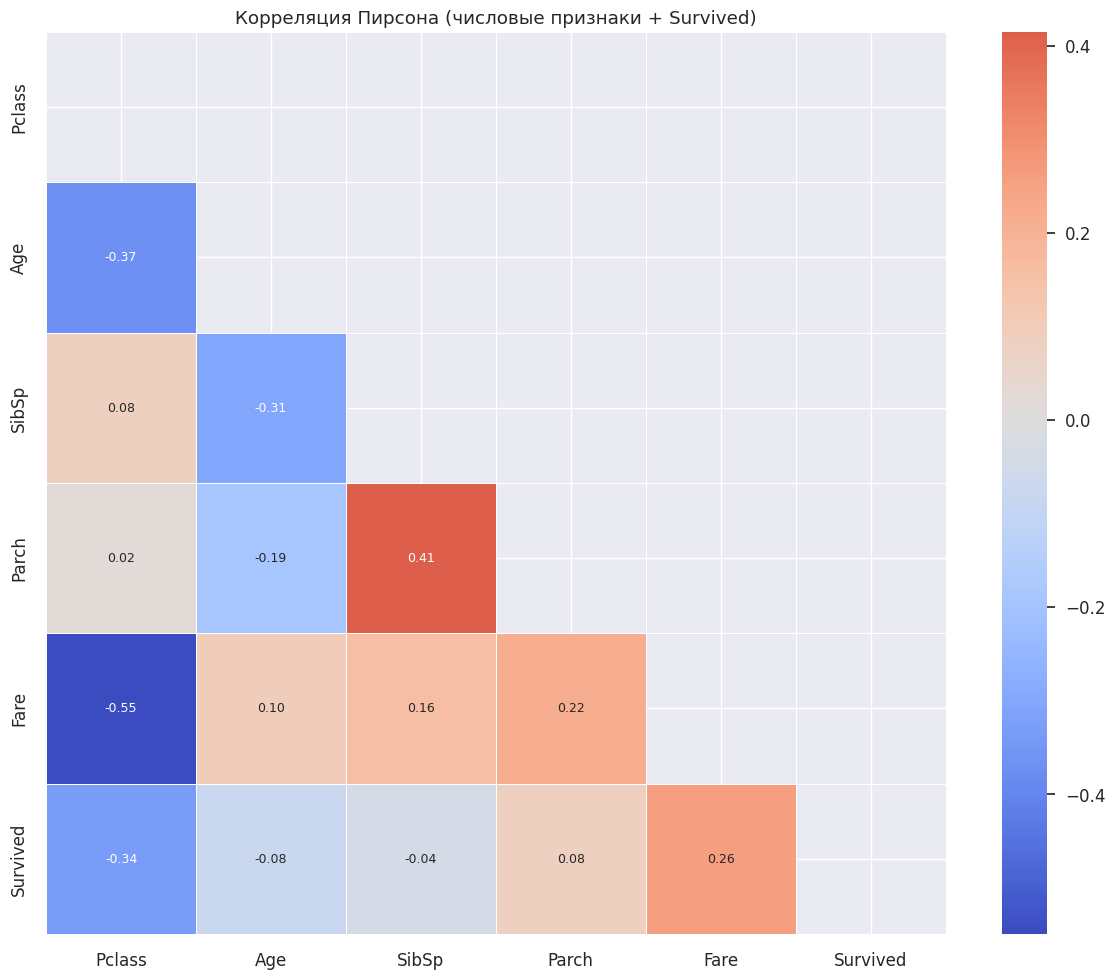

In [70]:
num_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
num_cols = [c for c in num_cols if c not in [target, 'PassengerId', 'Child']]

# Матрица корреляции Пирсона
plt.figure(figsize=(12,10))
corr_pearson = df[num_cols + [target]].corr(method='pearson')
mask = np.triu(np.ones_like(corr_pearson, dtype=bool))
sns.heatmap(corr_pearson, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=0.5, annot_kws={"size": 9})
plt.title('Корреляция Пирсона (числовые признаки + Survived)')
plt.tight_layout()
plt.show()


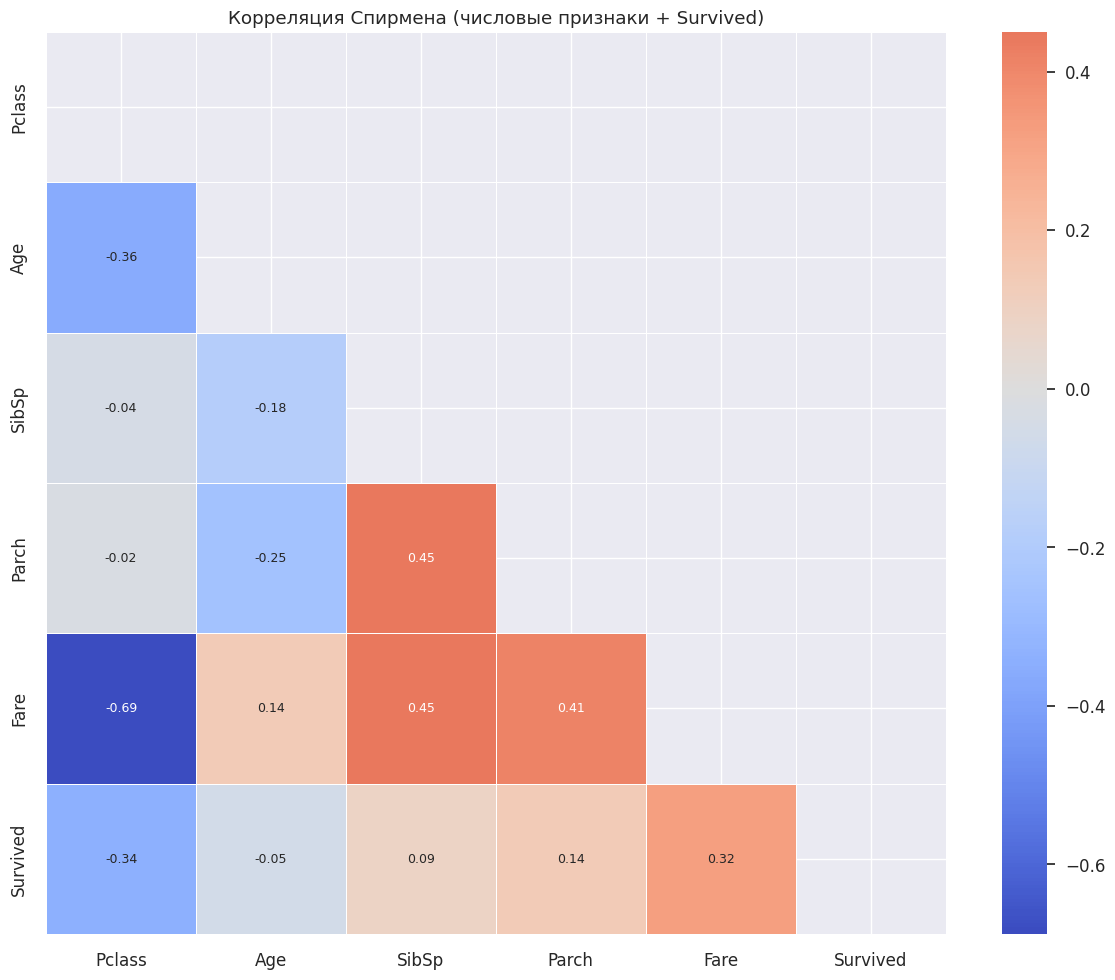

In [71]:
# Матрица корреляции Спирмена
plt.figure(figsize=(12,10))
corr_spearman = df[num_cols + [target]].corr(method='spearman')
sns.heatmap(corr_spearman, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=0.5, annot_kws={"size": 9})
plt.title('Корреляция Спирмена (числовые признаки + Survived)')
plt.tight_layout()
plt.show()

## 6. Feature Engineering

In [72]:
df_fe = df.copy()

# 1. Title из имени
def extract_title(name):
    if pd.isna(name):
        return "Unknown"
    m = re.search(r",\s*([^\.]+)\.", str(name))
    return m.group(1).strip() if m else "Unknown"

if "Name" in df_fe.columns:
    df_fe["Title"] = df_fe["Name"].apply(extract_title)
    rare_titles = ["Lady","Countess","Capt","Col","Don","Dr","Major","Rev","Sir","Jonkheer","Dona"]
    df_fe["Title"] = df_fe["Title"].replace(rare_titles, "Rare")
    df_fe["Title"] = df_fe["Title"].replace({"Mlle":"Miss","Ms":"Miss","Mme":"Mrs"})

# 2. Размер семьи и одиночество (одиночки)
df_fe["FamilySize"] = df_fe["SibSp"] + df_fe["Parch"] + 1
df_fe["IsAlone"] = (df_fe["FamilySize"] == 1).astype(int)

# 3. Наличие каюты
if "Cabin" in df_fe.columns:
    df_fe["Cabin_known"] = df_fe["Cabin"].notna().astype(int)

# 4. Размер группы по билету
if "Ticket" in df_fe.columns:
    ticket_counts = df_fe["Ticket"].value_counts()
    df_fe["TicketGroupSize"] = df_fe["Ticket"].map(ticket_counts)

# 5. Возрастные группы
if "Age" in df_fe.columns:
    df_fe["AgeGroup"] = pd.cut(
        df_fe["Age"],
        bins=[-1, 12, 18, 35, 60, 120],
        labels=["Child","Teen","Young","Adult","Senior"]
    )

# 6. Логарифм Fare (стоимость билета)
if "Fare" in df_fe.columns:
    df_fe["FareLog"] = np.log1p(df_fe["Fare"])

print("[FE] Созданы новые признаки: Title, FamilySize, IsAlone, Cabin_known, TicketGroupSize, AgeGroup, FareLog.")

[FE] Созданы новые признаки: Title, FamilySize, IsAlone, Cabin_known, TicketGroupSize, AgeGroup, FareLog.


In [73]:
# Проверка корреляции новых числовых признаков с таргетом
new_num = ["FamilySize", "IsAlone", "Cabin_known", "TicketGroupSize", "FareLog"]
new_corr = df_fe[new_num + [target]].corr(numeric_only=True)[target].sort_values(ascending=False)
print("Корреляция новых признаков с Survived:")
display(new_corr)

# Находим признак с максимальной абсолютной корреляцией
best_new_feat = new_corr.drop(target).abs().idxmax()
best_new_corr = new_corr[best_new_feat]
print(f"\nНаиболее коррелирующий новый признак: '{best_new_feat}' (корреляция {best_new_corr:.3f})")

Корреляция новых признаков с Survived:


,Survived
Survived,1.000000
FareLog,0.329862
Cabin_known,0.316912
TicketGroupSize,0.038247
FamilySize,0.016639
IsAlone,-0.203367



Наиболее коррелирующий новый признак: 'FareLog' (корреляция 0.330)


## 7. Подготовка данных (препроцессинг)

In [74]:
y = df_fe[target]
X = df_fe.drop(columns=[target, "PassengerId"], errors="ignore")

# числовые/категориальные признаки
num_features = X.select_dtypes(include=["int64","float64"]).columns.tolist()
cat_features = X.select_dtypes(include=["object","category"]).columns.tolist()

print("Числовые признаки:", num_features)
print("Категориальные признаки:", cat_features)

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_features),
        ("cat", categorical_transformer, cat_features)
    ],
    remainder="drop"
)

Числовые признаки: ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Child', 'FamilySize', 'IsAlone', 'Cabin_known', 'TicketGroupSize', 'FareLog']
Категориальные признаки: ['Name', 'Sex', 'Ticket', 'Cabin', 'Embarked', 'Title', 'AgeGroup']


In [75]:
# Разделение на тренировку/тестировку
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print(f"Обучающая выборка: {X_train.shape[0]} строк ({X_train.shape[0]/X.shape[0]*100:.1f}%)")
print(f"Тестовая выборка: {X_test.shape[0]} строк ({X_test.shape[0]/X.shape[0]*100:.1f}%)")

Обучающая выборка: 712 строк (79.9%)
Тестовая выборка: 179 строк (20.1%)


## 8. Важность признаков

In [76]:
# Baseline: логистическая регрессия
baseline = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", LogisticRegression(max_iter=2000, random_state=42))
])
baseline.fit(X_train, y_train)
y_pred_base = baseline.predict(X_test)
y_proba_base = baseline.predict_proba(X_test)[:,1]

print("Baseline (Logistic Regression):")
print(f"Accuracy: {accuracy_score(y_test, y_pred_base):.4f}")
print(f"F1: {f1_score(y_test, y_pred_base):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_base):.4f}")

Baseline (Logistic Regression):
Accuracy: 0.8436
F1: 0.7971
ROC-AUC: 0.8721


Top-15 важных признаков (Permutation Importance, ROC-AUC):


,0
Sex,0.061509
Title,0.033663
Pclass,0.008294
Cabin,0.005395
Child,0.002082
Parch,0.001423
FamilySize,0.001238
SibSp,0.000329
AgeGroup,0.000264
Ticket,0.000040


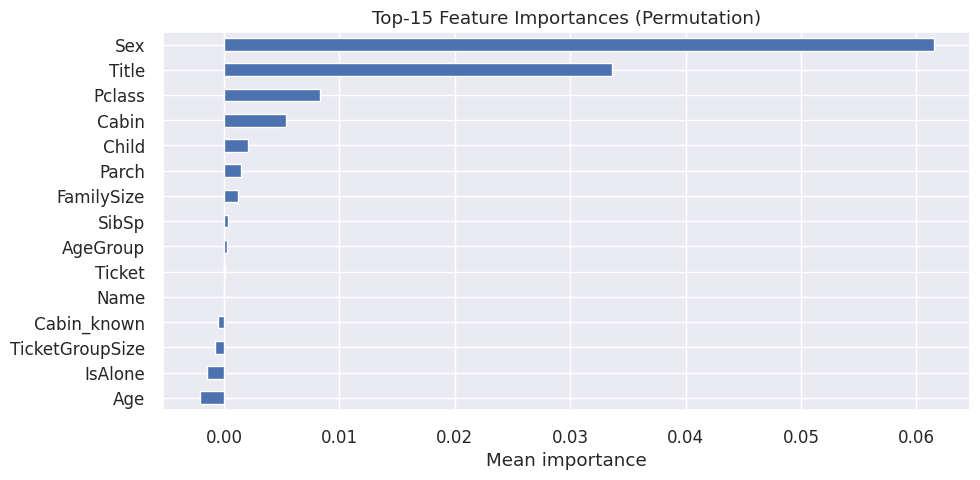

In [77]:
# Permutation Importance на Random Forest
rf_fi = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1))
])
rf_fi.fit(X_train, y_train)

perm = permutation_importance(rf_fi, X_test, y_test, n_repeats=10,
                              random_state=42, scoring="roc_auc")
fi = pd.Series(perm.importances_mean, index=X_test.columns).sort_values(ascending=False)

print("Top-15 важных признаков (Permutation Importance, ROC-AUC):")
display(fi.head(15))

plt.figure(figsize=(10,5))
fi.head(15).plot(kind='barh')
plt.title('Top-15 Feature Importances (Permutation)')
plt.xlabel('Mean importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## 9. Эксперименты с моделями и кросс-валидация

In [78]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models = {
    "Linear (LogReg)": LogisticRegression(max_iter=2000, random_state=42),
    "Tree (DecisionTree)": DecisionTreeClassifier(random_state=42),
    "Trees (RandomForest)": RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1),
    "Boosting (HistGB)": HistGradientBoostingClassifier(random_state=42),
    "NeuralNet (MLP)": MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=400, random_state=42)
}

results = []
for name, est in models.items():
    pipe = Pipeline(steps=[("preprocess", preprocess), ("model", est)])
    scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring="roc_auc")
    results.append({
        "Model": name,
        "ROC_AUC_mean": scores.mean(),
        "ROC_AUC_std": scores.std()
    })

results_df = pd.DataFrame(results).sort_values("ROC_AUC_mean", ascending=False)
print("Результаты кросс-валидации (5 фолдов, ROC-AUC):")
display(results_df)

Результаты кросс-валидации (5 фолдов, ROC-AUC):


,Model,ROC_AUC_mean,ROC_AUC_std
4,NeuralNet (MLP),0.899093,0.018630
2,Trees (RandomForest),0.890201,0.023270
3,Boosting (HistGB),0.888243,0.013520
0,Linear (LogReg),0.884410,0.019884
1,Tree (DecisionTree),0.812295,0.025636


In [79]:
# Выбираем лучшую модель
best_row = results_df.iloc[0]
best_model_name = best_row["Model"]
print(f"\nЛучшая модель по кросс-валидации: {best_model_name}")

best_estimator = models[best_model_name]
best_pipe = Pipeline(steps=[("preprocess", preprocess), ("model", best_estimator)])


Лучшая модель по кросс-валидации: NeuralNet (MLP)


Финальные метрики на тестовой выборке:
Accuracy:  0.7989
Precision: 0.7200
Recall:    0.7826
F1-score:  0.7500
ROC-AUC:   0.8618

Confusion Matrix:
[[89 21]
 [15 54]]

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.81      0.83       110
           1       0.72      0.78      0.75        69

    accuracy                           0.80       179
   macro avg       0.79      0.80      0.79       179
weighted avg       0.80      0.80      0.80       179



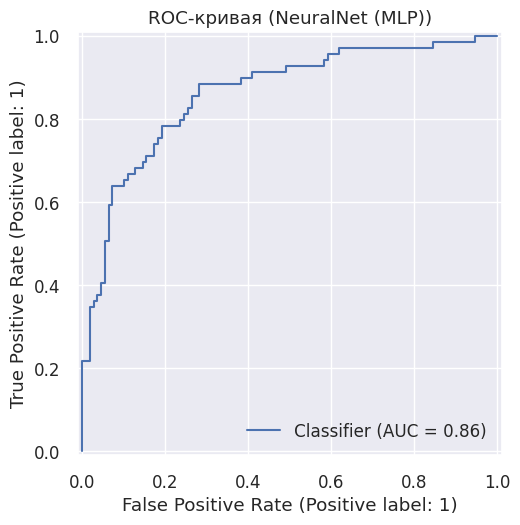

In [80]:
# Финальная оценка на отложенной тестовой выборке
best_pipe.fit(X_train, y_train)
final_pred = best_pipe.predict(X_test)
final_proba = best_pipe.predict_proba(X_test)[:,1]

final_acc = accuracy_score(y_test, final_pred)
final_prec = precision_score(y_test, final_pred)
final_rec = recall_score(y_test, final_pred)
final_f1 = f1_score(y_test, final_pred)
final_auc = roc_auc_score(y_test, final_proba)

print("Финальные метрики на тестовой выборке:")
print(f"Accuracy:  {final_acc:.4f}")
print(f"Precision: {final_prec:.4f}")
print(f"Recall:    {final_rec:.4f}")
print(f"F1-score:  {final_f1:.4f}")
print(f"ROC-AUC:   {final_auc:.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, final_pred))
print("\nClassification Report:")
print(classification_report(y_test, final_pred))

RocCurveDisplay.from_predictions(y_test, final_proba)
plt.title(f"ROC-кривая ({best_model_name})")
plt.show()